In [1]:
import numpy as np
import pandas as pd
import multiprocessing as mp
import researchpy as rp
from inspect import signature
from matplotlib import pyplot as plt
from dacbench.logger import Logger, log2dataframe, load_logs
import seaborn as sns
import glob
from plotting import plot_performance_over_time, plot_final_performance_comparison, plot_improvement_probability, plot_configuration_footprint, plot_hp_importance, plot_deepcave

/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/dacbench/envs/__init__.py:35: UserWarning: CMA-ES Benchmark not installed. If you want to use this benchmark, please follow the installation guide.
  warnings.warn(  # noqa: B028
/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/dacbench/benchmarks/__init__.py:26: UserWarning: CMA-ES Benchmark not installed. If you want to use this benchmark, please follow the installation guide.
  warnings.warn(  # noqa: B028


DACBench Gym registration failed - make sure you have all dependencies installed and their instance sets in the right path!


In [2]:
def toDataFrame(glob_path, col_name, col_index, method):
    d =  [log2dataframe(load_logs(path)) for path in glob.glob(glob_path)]

    df = pd.DataFrame([s[col_name][col_index] for s in d])

    df['method'] = method

    return df

def toChunkedDataFrame(glob_path, col_name, col_index, chunk_size):
    d =  [log2dataframe(load_logs(path)) for path in glob.glob(glob_path)]

    df = pd.DataFrame([s[col_name][col_index] for s in d]).transpose()

    result_df = pd.DataFrame()
    for col in df.columns:
        reshaped_data = df[col].values.reshape(-1, chunk_size)
        result_df[col] = reshaped_data.mean(axis=1)

    result_df.reset_index()

    result_df['epoch'] = result_df.index + 1
    result_df = result_df.melt(id_vars=['epoch'])

    return result_df

sns.set_style('whitegrid')
palette = sns.color_palette("colorblind")
sns.set_palette(palette)

          0 method
0  0.976911   dowg
1  0.981091   dowg
2  0.991143   dowg
3  0.992635   dowg
4  0.990048   dowg
5  0.987858   dowg
6  0.990943   dowg
7  0.989550   dowg


   Variable     N    Mean     SD      SE  95% Conf.  Interval
0       0.0  10.0  0.9914  0.001  0.0003     0.9907    0.9921


   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.9887  0.0012  0.0004     0.9878    0.9896


   Variable    N    Mean      SD      SE  95% Conf.  Interval
0       0.0  9.0  0.9911  0.0013  0.0004     0.9902    0.9921


   Variable    N    Mean      SD      SE  95% Conf.  Interval
0       0.0  9.0  0.9914  0.0011  0.0004     0.9905    0.9922


   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.9918  0.0004  0.0001     0.9915    0.9922


   Variable    N    Mean      SD     SE  95% Conf.  Interval
0       0.0  8.0  0.9875  0.0055  0.002     0.9829    0.9922


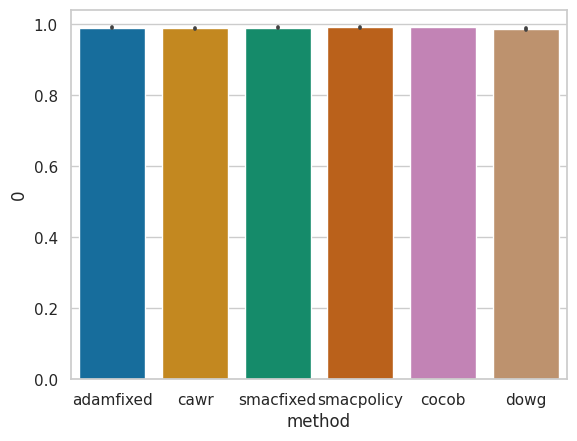

In [28]:
cocob_ta_mnist = toDataFrame('./results_cluster/results/COCOB_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cocob')
adamfixed_ta_mnist = toDataFrame('./results_cluster/results/Adam_fixed_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'adamfixed')
smacfixed_ta_mnist = toDataFrame('./results_cluster/results/SMAC_fixed_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'smacfixed')
cawr_ta_mnist = toDataFrame('./results_cluster/results/CAWR_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cawr')
smacpolicy_ta_mnist = toDataFrame('./results_cluster/results/smacpolicy_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'smacpolicy')
dowg_ta_mnist = toDataFrame('./results_cluster/results/DoWG_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'dowg')
print(dowg_ta_mnist)
cdowg_ta_mnist = toDataFrame('./results_cluster/results/CDoWG_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cdowg')
data = pd.concat([adamfixed_ta_mnist, cawr_ta_mnist, smacfixed_ta_mnist, smacpolicy_ta_mnist, cocob_ta_mnist, dowg_ta_mnist])
sns.barplot(data=data, x='method', y=0)
print(rp.summary_cont(adamfixed_ta_mnist[0]))
print(rp.summary_cont(cawr_ta_mnist[0]))
print(rp.summary_cont(smacfixed_ta_mnist[0]))
print(rp.summary_cont(smacpolicy_ta_mnist[0]))
print(rp.summary_cont(cocob_ta_mnist[0]))
print(rp.summary_cont(dowg_ta_mnist[0]))
# print(rp.summary_cont(cdowg_ta_mnist[0]))



   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.9265  0.0018  0.0006     0.9252    0.9277


   Variable     N   Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.911  0.0037  0.0012     0.9083    0.9136


   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.9248  0.0034  0.0011     0.9223    0.9272


   Variable    N    Mean      SD      SE  95% Conf.  Interval
0       0.0  9.0  0.9237  0.0041  0.0014     0.9206    0.9269


   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.9244  0.0025  0.0008     0.9226    0.9261


   Variable    N    Mean      SD      SE  95% Conf.  Interval
0       0.0  8.0  0.8768  0.0528  0.0187     0.8326    0.9209


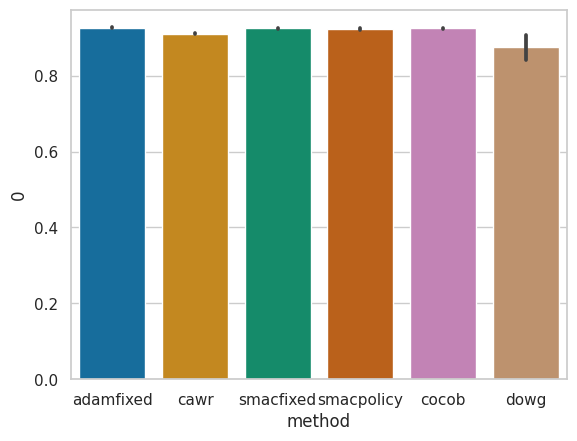

In [23]:
cocob_ta_fmnist = toDataFrame('./results_cluster/results/COCOB_fmnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cocob')
adamfixed_ta_fmnist = toDataFrame('./results_cluster/results/Adam_fixed_fmnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'adamfixed')
smacfixed_ta_fmnist = toDataFrame('./results_cluster/results/SMAC_fixed_fashion_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'smacfixed')
cawr_ta_fmnist = toDataFrame('./results_cluster/results/CAWR_fmnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cawr')
smacpolicy_ta_fmnist = toDataFrame('./results_cluster/results/smacpolicy_fashion_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'smacpolicy')
dowg_ta_fmnist = toDataFrame('./results_cluster/results/DoWG_fashion_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'dowg')
data = pd.concat([adamfixed_ta_fmnist, cawr_ta_fmnist, smacfixed_ta_fmnist, smacpolicy_ta_fmnist, cocob_ta_fmnist, dowg_ta_fmnist])
sns.barplot(data=data, x='method', y=0)
print(rp.summary_cont(adamfixed_ta_fmnist[0]))
print(rp.summary_cont(cawr_ta_fmnist[0]))
print(rp.summary_cont(smacfixed_ta_fmnist[0]))
print(rp.summary_cont(smacpolicy_ta_fmnist[0]))
print(rp.summary_cont(cocob_ta_fmnist[0]))
print(rp.summary_cont(dowg_ta_fmnist[0]))



   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.8479  0.0078  0.0025     0.8423    0.8535


   Variable    N    Mean      SD      SE  95% Conf.  Interval
0       0.0  9.0  0.8741  0.0037  0.0012     0.8712     0.877


   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.8545  0.0054  0.0017     0.8506    0.8584


   Variable    N    Mean    SD      SE  95% Conf.  Interval
0       0.0  9.0  0.8698  0.01  0.0033      0.862    0.8775


   Variable     N    Mean    SD      SE  95% Conf.  Interval
0       0.0  10.0  0.8255  0.01  0.0032     0.8183    0.8327


   Variable     N   Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.841  0.0125  0.0039      0.832    0.8499


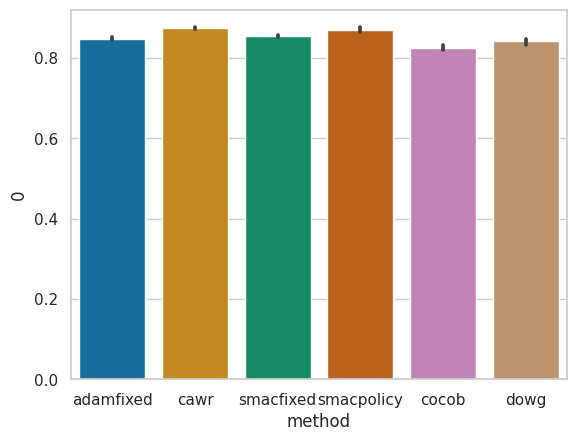

In [26]:
cocob_ta_cifar10 = toDataFrame('./results_cluster/results/COCOB_cifar10_30/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cocob')
adamfixed_ta_cifar10 = toDataFrame('./results_cluster/results/Adam_fixed_cifar10_30/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'adamfixed')
# stormplus_cifar10 = toDataFrame('./results_cluster/results/STORMplus_cifar10/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'stormplus')
smacfixed_ta_cifar10 = toDataFrame('./results_cluster/results/SMAC_fixed_cifar10/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'smacfixed')
smacpolicy_ta_cifar10 = toDataFrame('./results_cluster/results/smacpolicy_cifar10/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'smacpolicy')
# smacpolicy_ta_cifar10_seed = toDataFrame('./results_cluster/results/smacpolicy_cifar10_same_seed/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'smacpolicyseed')
dowg_ta_cifar10 = toDataFrame('./results_cluster/results/DoWG_cifar10_30/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'dowg')
cawr_ta_cifar10 = toDataFrame('./results_cluster/results/CAWR_cifar10/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cawr')
data = pd.concat([adamfixed_ta_cifar10, cawr_ta_cifar10, smacfixed_ta_cifar10, smacpolicy_ta_cifar10, cocob_ta_cifar10, dowg_ta_cifar10])
sns.barplot(data=data, x='method', y=0)
print(rp.summary_cont(adamfixed_ta_cifar10[0]))
print(rp.summary_cont(cawr_ta_cifar10[0]))
print(rp.summary_cont(smacfixed_ta_cifar10[0]))
print(rp.summary_cont(smacpolicy_ta_cifar10[0]))
# print(rp.summary_cont(smacpolicy_ta_cifar10_seed[0]))
print(rp.summary_cont(cocob_ta_cifar10[0]))
print(rp.summary_cont(dowg_ta_cifar10[0]))



   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.5405  0.0065  0.0021     0.5359    0.5452


   Variable    N    Mean      SD      SE  95% Conf.  Interval
0       0.0  8.0  0.5874  0.0047  0.0017     0.5835    0.5914


   Variable     N    Mean      SD     SE  95% Conf.  Interval
0       0.0  10.0  0.5549  0.0096  0.003      0.548    0.5618


   Variable    N    Mean     SD     SE  95% Conf.  Interval
0       0.0  9.0  0.5811  0.018  0.006     0.5673    0.5949


   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.5094  0.0091  0.0029     0.5029    0.5159


   Variable     N    Mean      SD      SE  95% Conf.  Interval
0       0.0  10.0  0.5111  0.0097  0.0031     0.5041    0.5181


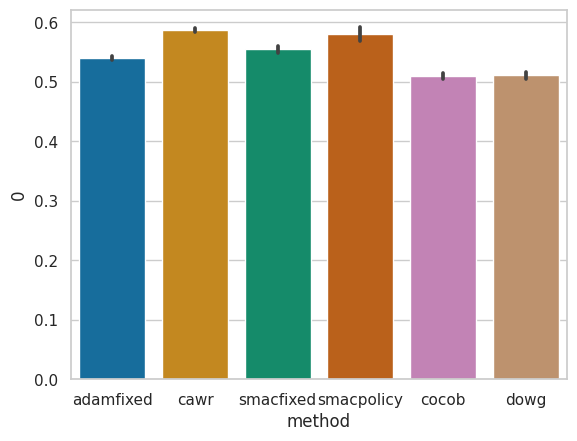

In [27]:
cocob_ta_cifar100 = toDataFrame('./results_cluster/results/COCOB_cifar100/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cocob')
adamfixed_ta_cifar100 = toDataFrame('./results_cluster/results/Adam_fixed_cifar100/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'adamfixed')
dowg_cifar100 = toDataFrame('./results_cluster/results/DoWG_cifar100/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'dowg')
smacfixed_ta_cifar100 = toDataFrame('./results_cluster/results/SMAC_fixed_cifar100/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'smacfixed')
smacpolicy_ta_cifar100 = toDataFrame('./results_cluster/results/smacpolicy_cifar100/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'smacpolicy')
cawr_ta_cifar100 = toDataFrame('./results_cluster/results/CAWR_cifar100/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cawr')
data = pd.concat([adamfixed_ta_cifar100, cawr_ta_cifar100, smacfixed_ta_cifar100, smacpolicy_ta_cifar100, cocob_ta_cifar100, dowg_cifar100])
sns.barplot(data=data, x='method', y=0)
print(rp.summary_cont(adamfixed_ta_cifar100[0]))
print(rp.summary_cont(cawr_ta_cifar100[0]))
print(rp.summary_cont(smacfixed_ta_cifar100[0]))
print(rp.summary_cont(smacpolicy_ta_cifar100[0]))
print(rp.summary_cont(cocob_ta_cifar100[0]))
print(rp.summary_cont(dowg_cifar100[0]))


Text(0, 0.5, 'Learning Rate')

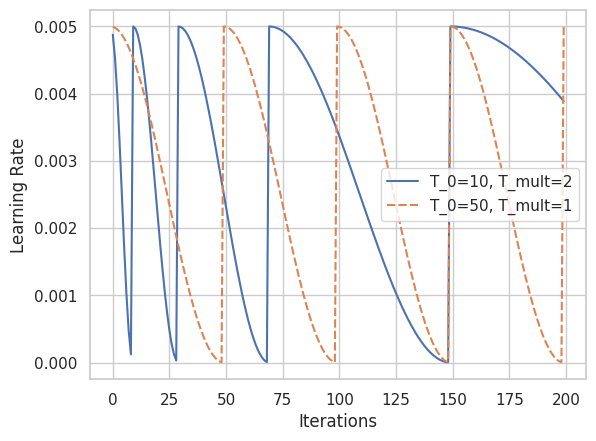

In [26]:
from dacbench_custom.cosine_annealing_agent import CosineAnnealingWRAgent as CAWR

def cawr_df(cawr):
    values = []
    for i in range(200):
        values.append(cawr.act())
    
    return pd.DataFrame(values)

cawr = CAWR(None, 10, 0, 0.005, 2)
cawr2 = CAWR(None, 50, 0, 0.005, 1)

df = pd.concat([cawr_df(cawr), cawr_df(cawr2)], axis=1)

df.columns = ['T_0=10, T_mult=2', 'T_0=50, T_mult=1']

sns.lineplot(data=df)
plt.xlabel('Iterations')
plt.ylabel('Learning Rate')

In [13]:
import json

# Opening JSON file
f = open('results_cluster/results/smacpolicy_50_1/smac3_output/99a409bda8989f3434809edbb78bacbd/1/runhistory.json')

# returns JSON object as 
# a dictionary
data = json.load(f)

# Iterating through the json
# list
maxI = data['data'][0]
for i in data['data']:
    if i[4] < maxI[4]:
        maxI = i

print(maxI)

print(data['configs']['{}'.format(maxI[0])])

# Closing file
f.close()

[34, None, 1791095845, None, -0.3692497942919244, 12583.780605077744, 1, 1725140654.74826, 1725153238.532099, {}]
{'x0': 5.1646632886731545e-06, 'x1': 0.0023804455900105245, 'x10': 0.0032852016451236465, 'x11': 0.004216616069597613, 'x12': 0.0009186970593800087, 'x13': 0.0042807961899368595, 'x14': 0.0018218273992851397, 'x15': 0.004461369646380863, 'x16': 0.00013855870061182495, 'x17': 0.0004269506956158531, 'x18': 0.004907052328770562, 'x19': 0.003047509628867483, 'x2': 0.0020881617340709163, 'x20': 0.0008460709234684527, 'x21': 0.00324950576544845, 'x22': 0.00018487534179678912, 'x23': 0.0015580695673035234, 'x24': 0.0016173959849453768, 'x25': 0.0030372094675727677, 'x26': 0.0032541562833784854, 'x27': 0.004230272996182347, 'x28': 0.0046379047129877175, 'x29': 0.003302288638055498, 'x3': 0.002890869592042691, 'x30': 0.001993577718145042, 'x31': 0.00483306246321071, 'x32': 0.0007703958591617871, 'x33': 0.004475434043243242, 'x34': 0.0015550653394242075, 'x35': 0.00274244544833052, '